clone the repo if you are on cloud

In [ ]:
# !git clone --depth 1 https://github.com/OussamaMadev/face-anti-spoofing-pipline
# %cd face-anti-spoofing-pipline

In [1]:
import numpy as np
import tensorflow as tf
import trainingPipeline
from trainingPipeline import TrainingPipeline
import architectures
from tensorflow.keras import layers, models
import importlib
importlib.reload(trainingPipeline)
importlib.reload(architectures)

<module 'architectures' from 'c:\\Users\\ThinkPad\\Documents\\UNIVERSITY\\PFE2\\architectures.py'>

you can define multiple keras models here 
and file the configes list then run multiple training at ones

check models.py

be carefull with paths

double check you configs befor launching long experiments

In [ ]:

def init_model(input_shape=(224, 224, 3)):
    return architectures.mc_resnet_rgb_hsv(input_shape=input_shape)


print("Model name: " + init_model().name)
print("Number of parameters: " + str(init_model().count_params()))

In [ ]:
configs_example = [
    {
        "filtering_params": {
            "data_map_path": "data_maps/CASIA_FASD_V3_10percent_uniformSampling.json",
        },
        
        "data_params": {
            "dataset_path": "data/CASIA_FASD_v3_224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32,
            
            "validation_subjects_number": 3, # < 5 # Number of subjects to be used for validation (the will not be used for training)
            "get_random_subjects_for_validation": 1, # 1 for random selection, 0 for fixed selection (the first N subjects in the dataset)
            "validation_dataset_baleance": 0, # 0 for unbalanced, 1 for balanced
        },
        
        "augmentation_params": {
            "rotation_range": 0.1,
            "horizontal_flip": 1,
            "brightness_delta": 0.1, # -1.0 to 1.0, 0 for no change
            # new
            "zoom_range": [0.8, 1.0], # [lower, upper], 1.0 for no change
            "contrast_range": [0.9, 1.1], # [lower, upper], 1.0 for no change
            "saturation_range": [0.9, 1.1], # [lower, upper], 1.0 for no change
            "hue_delta": 0.05, # [0.0, 0.5], 0 for no change
            "gaussian_noise": 0.01, # 0 for no noise, otherwise the standard deviation of the Gaussian noise to be added to the images
        },
        
        "model_params": {
            "model_init_function": architectures.mc_resnet_rgb_hsv,  # Reference to the model initialization function
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None,  # To be filled after model initialization
            "note" : None ,# optional note about the model architecture or the weights used (if any)

            # new 
            "label_smoothing" : 0.1, # 0 for no label smoothing, otherwise the factor for label smoothing (between 0 and 1)
            "isFocalLoss" : 0, # 0 for no focal loss, 1 for focal loss
            "focal_alpha" : 0.25, # alpha parameter for focal loss
            "focal_gamma" : 2.0, # gamma parameter for focal loss
            "apply_class_balancing" : 0, # 0 for no class balancing, 1 for class balancing
                       
        },
        
        "training_params": {
            "early_stopping_patience": 5, # None or negative for no early stopping
            "learning_rate": 0.0001,# adam optimizer learning rate
            "initial_epochs": 25,

            # new parameters for learning rate reduction on plateau
            "ReduceLROnPlateau_patience": 3, # None for no learning rate reduction on plateau, otherwise number of epochs with no improvement after which learning rate will be reduced
            "ReduceLROnPlateau_factor": 0.5, # None for no learning rate reduction on plateau, otherwise factor by which the learning rate will be reduced. new_lr = lr * factor
            # ==============================================

            # new parameters for AdamW optimizer
            "isAdamW": 0, # 0 for Adam, 1 for AdamW
        }      
    }
]


In [ ]:
trainPipe = TrainingPipeline(configs_example, 
                             experiment_id="experiment_local_test",
                             logs_output_path="./experiment_records", 
                             models_output_path="./experiment_records", 
                             note="Testing the training pipeline with a simple configuration.")



In [ ]:
trainPipe.run()

In [ ]:
architectures.hsv_ConvNeXtTiny(input_shape=(224, 224, 3)).count_params()

In [ ]:
tf.keras.applications.MobileNetV3Large(input_shape=(224, 224, 3), weights=None ,include_top=True, classes=2 ).count_params()


In [ ]:
tf.keras.applications.VGG16(input_shape=(224, 224, 3), weights=None ,include_top=False, classes=2 ).count_params()

In [ ]:
tf.keras.applications.EfficientNetV2S(input_shape=(224, 224, 3), weights=None ,include_top=False, classes=2 ).count_params()

In [3]:
import DataLoaderPipeline as dplmodule
from DataLoaderPipeline import DataLoaderPipeline
import importlib
importlib.reload(dplmodule)
config = configs_example[0]
all_subjects = [f"{i:02d}" for i in range(1, 51)]  # Generate subject IDs from '01' to '50'.
train_subs = all_subjects[:15]
val_subs = all_subjects[15:20] 
test_subs = all_subjects[20:] 

dlp = DataLoaderPipeline(data_params=config["data_params"],
                         filtering_params=config["filtering_params"],
                         augmentation_params=config["augmentation_params"])

Successfully loaded 50 subjects from JSON.


In [4]:
ds = dlp.build_pipeline(test_subs,False,False)
ds = ds.take(100)
len(ds)

100

In [5]:
model = architectures.build_resnet50v2_rgb_v4(input_shape=(224, 224, 3))
model.load_weights("./experiment_047_20260429-014533_1_model_resNet50V2_FASD_RGB_V4.keras")
# y = model.predict(ds.take(10))

In [ ]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy() , metrics=['accuracy'])
trainPipe.compute_metrics(ds, model)

In [7]:
y_true_list = []
y_pred_list = []

for images, labels in ds:
    preds = model(images, training=False)
    y_true_list.append(labels.numpy())
    y_pred_list.append(preds.numpy())


In [8]:


y_true = np.concatenate(y_true_list).ravel()
y_pred = np.concatenate(y_pred_list).ravel()
# y_pred = np.array([1] * len(y_pred))

In [9]:

import sklearn
import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import interp1d

resolution = 32 * 100
thresholds = [i / resolution for i in range(resolution + 1)] # Normalize thresholds to be between 0 and 1


def compute_eer(label, pred):
    # all fpr, tpr, fnr, fnr, threshold are lists (in the format of np.array)
    fpr, tpr, threshold = sklearn.metrics.roc_curve(label, pred)
    fnr = 1 - tpr

    # the threshold of fnr == fpr
    eer_threshold = threshold[np.nanargmin(np.absolute((fnr - fpr)))]

    # theoretically eer from fpr and eer from fnr should be identical but they can be slightly differ in reality
    eer_1 = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    eer_2 = fnr[np.nanargmin(np.absolute((fnr - fpr)))]

    # return the mean of eer from fpr and from fnr
    eer = (eer_1 + eer_2) / 2

    eer4 = brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, threshold)(eer4)
    
    return float(eer), float(eer_1), float(eer_2), float(eer4), float(eer_threshold),float(thresh)

def f1(label, pred):
    fpr, tpr, _ = sklearn.metrics.roc_curve(label, pred)
    fnr = 1 - tpr
    eer_1 = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    eer_2 = fnr[np.nanargmin(np.absolute((fnr - fpr)))]
    eer = (eer_1 + eer_2) / 2 
    return eer

def f2(label, pred):
    fpr, tpr, _ = sklearn.metrics.roc_curve(label, pred)
    eer = brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer

def f3(label, pred):
    fpr, tpr, _ = sklearn.metrics.roc_curve(label, pred)
    frr = 1 - tpr
    return fpr[np.nanargmin(np.absolute(fpr - frr))]

In [10]:
compute_eer(y_true, y_pred)

(0.018168801319964373,
 0.018084669132757913,
 0.018252933507170832,
 0.018252933507170877,
 0.27617669105529785,
 0.27357802439320106)

In [ ]:
f1(y_true, y_pred)


In [ ]:
f2(y_true, y_pred)

In [ ]:
e = f3(y_true, y_pred)
e


In [ ]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_true, y_pred)
fnr = 1 - tpr
print(" FPR: ", fpr)
print(" TPR: ", tpr)
print(" FNR: ", fnr)
print("Thresholds: ", thresholds)

In [12]:
fps = []
fns = []
for threshold in thresholds:
    y_pred_binary = [1 if p >= threshold else 0 for p in y_pred]
    # count fnr and fpr for this threshold
    fpr = sum((y_true[i] == 0 and y_pred_binary[i] == 1) for i in range(len(y_true)))/sum(y_true[i] == 0 for i in range(len(y_true)))
    fnr = sum((y_true[i] == 1 and y_pred_binary[i] == 0) for i in range(len(y_true)))/sum(y_true[i] == 1 for i in range(len(y_true)))
    fps.append(fpr)
    fns.append(fnr)

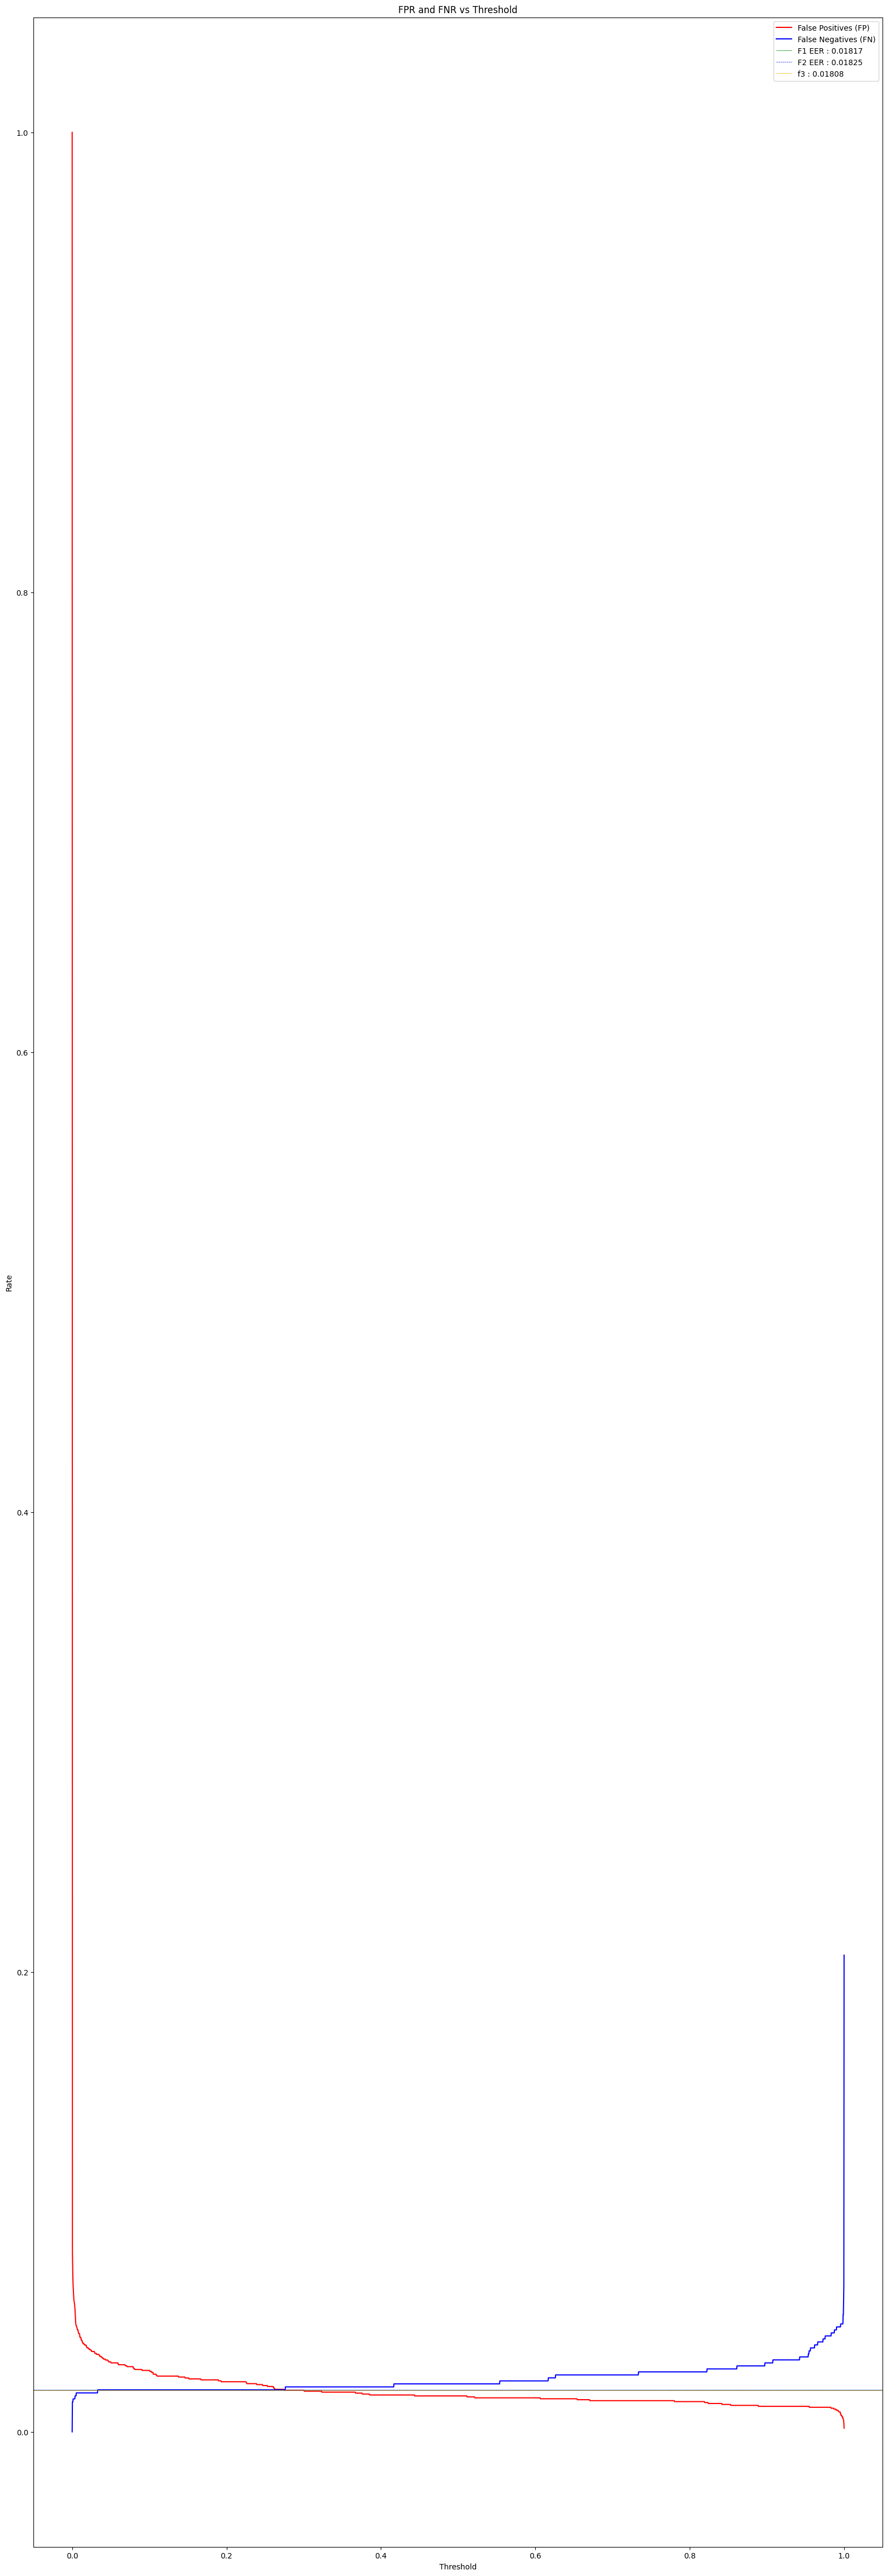

In [13]:
f1_eer = f1(y_true, y_pred)
f2_eer = f2(y_true, y_pred)

#Plot FPR and FNR against thresholds
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 60))
plt.plot(thresholds, fps, label='False Positives (FP)', color='red')
plt.plot(thresholds, fns, label='False Negatives (FN)', color='blue')

plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('FPR and FNR vs Threshold')
plt.axhline(y=f1_eer, color='green', linestyle='-', label=f'F1 EER : {f1_eer:.5f}', linewidth=0.5)
plt.axhline(y=f2_eer, color='blue', linestyle='--', label=f'F2 EER : {f2_eer:.5f}', linewidth=0.5)
# plt.axhline(y=eer[2], color='red', linestyle='-', label=f'EER : {eer[2]:.5f}', linewidth=0.5)
# plt.axhline(y=eer[3], color='black', linestyle='-', label=f'EER : {eer[3]:.5f}', linewidth=0.5)
# plt.axvline(x=eer[4], color='purple', linestyle='-', label=f'EER Threshold : {eer[4]:.5f}', linewidth=0.5)
# plt.axvline(x=eer[5], color='purple', linestyle='-', label=f'EER Threshold : {eer[5]:.5f}', linewidth=0.5)

plt.axhline(y=f3(y_true, y_pred), color='orange', linestyle='-', label=f'f3 : {f3(y_true, y_pred):.5f}', linewidth=0.5)




plt.legend()
plt.show()


In [14]:
eer = compute_eer(y_true, y_pred)
print("EER: ", eer)

EER:  (0.018168801319964373, 0.018084669132757913, 0.018252933507170832, 0.018252933507170877, 0.27617669105529785, 0.27357802439320106)
